# Transaction costs on a day of crypto trades, with brrrrr

A synthetic day of trades and quotes for three coins, made in the first cell: no download, no account, a few seconds. The data is made to behave like a real market where it matters here: prices that random-walk, quotes a few ticks wide, trades that walk the book and move the price, and orders split into runs of trades on one side. No database and no loading step: the queries read the Parquet files where they are.

We compute, each in a few lines of SQL:

1. one-minute bars and VWAP,
2. the quoted spread,
3. what each trade paid against the mid (an as-of join of every trade with the quote in force),
4. markouts: where the mid went 1, 10 and 60 seconds after each trade,
5. realised volatility by the hour.

```
pip install brrrrr polars matplotlib
```

In [1]:
import time
import brrrrr
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3), "figure.dpi": 80, "axes.grid": True, "grid.alpha": 0.3})
con = brrrrr.connect()

def q(sql):
    """Runs a query, says how long it took, returns a Polars DataFrame."""
    start = time.perf_counter()
    df = con.sql(sql).pl()
    print(f"{len(df):,} rows in {time.perf_counter() - start:.2f} s")
    return df

## The data

Per coin: quotes at random times, more of them in the busy hours; a mid that random-walks between them and is pushed by the trades; a spread of a few basis points. Each trade buys at the ask or sells at the bid, plus a little more the bigger it is (it walks the book), and its size in dollars is log-normal. Sides come in runs, as large orders are split. Both tables go to Parquet in `data/`, in time order.

In [2]:
import pathlib
import numpy as np
import polars as pl

rng = np.random.default_rng(42)
DAY_US, START = 86_400_000_000, 1_709_251_200_000_000  # 2024-03-01, UTC
COINS = {"BTC": (62_000.0, 0.5, 120_000), "ETH": (3_400.0, 1.0, 80_000), "SOL": (130.0, 3.0, 50_000)}  # price, spread (bps), trades
hours = 1 + 0.7 * np.sin((np.arange(24) - 9) / 24 * 2 * np.pi)  # busiest mid-afternoon UTC

def times(n):
    h = rng.choice(24, n, p=hours / hours.sum())
    return np.sort(START + h * 3_600_000_000 + rng.integers(0, 3_600_000_000, n))

trades, quotes = [], []
for coin, (p0, spread_bps, n) in COINS.items():
    qt, tt = times(3 * n), times(n)
    tq = np.searchsorted(qt, tt, "right") - 1  # each trade's quote in force
    keep = tq >= 0
    tt, tq, m = tt[keep], tq[keep], keep.sum()
    side = 1 - 2 * (np.cumsum(rng.random(m) < 0.15) % 2)  # +1 buy, -1 sell, in runs
    usd = np.exp(rng.normal(8, 1.6, m))  # about $3,000 typical, some far larger
    depth = np.sqrt(usd / 10_000)
    # the mid: noise between quotes, plus the push of the trades since the last one
    push = np.zeros(len(qt))
    np.add.at(push, np.minimum(tq + 1, len(qt) - 1), side * depth * 0.6e-4)
    mid = p0 * np.exp(np.cumsum(rng.normal(0, 0.025 / np.sqrt(len(qt)), len(qt)) + push))
    half = mid * spread_bps / 2e4 * rng.lognormal(0, 0.3, len(qt))
    bid, ask = np.round(mid - half, 2), np.round(mid + half, 2)
    price = np.where(side > 0, ask[tq], bid[tq]) * (1 + side * depth * 0.4e-4)
    trades.append(pl.DataFrame({"ts": tt, "symbol": coin, "side": np.where(side > 0, "buy", "sell"),
                                "price": np.round(price, 2), "size": np.round(usd / price, 4)}))
    quotes.append(pl.DataFrame({"ts": qt, "symbol": coin, "bid": bid, "ask": ask,
                                "bid_size": np.round(rng.exponential(30_000, len(qt)) / mid, 4),
                                "ask_size": np.round(rng.exponential(30_000, len(qt)) / mid, 4)}))

pathlib.Path("data").mkdir(exist_ok=True)
for name, parts in [("trades", trades), ("quotes", quotes)]:
    df = pl.concat(parts).with_columns(pl.col("ts").cast(pl.Datetime("us", "UTC"))).sort("ts")
    df.write_parquet(f"data/{name}.parquet")
    print(name, f"{len(df):,} rows")

trades 250,000 rows
quotes 750,000 rows


Two views name the files; a query could as well read `'data/trades.parquet'` directly:

In [3]:
con.sql("""
CREATE VIEW trades AS SELECT * FROM 'data/trades.parquet';
CREATE VIEW quotes AS SELECT * FROM 'data/quotes.parquet'
""")
q("""
SELECT symbol, count(*) AS trades, sum(size) AS volume, sum(price * size) / 1e6 AS usd_m
FROM trades GROUP BY symbol ORDER BY usd_m DESC
""")

3 rows in 0.03 s


symbol,trades,volume,usd_m
str,u64,f64,f64
"""BTC""",120000,20197.9957,1286.475541
"""ETH""",80000,253360.0792,874.245389
"""SOL""",50000,4.1069e6,521.628429


In [4]:
q("SELECT symbol, count(*) AS quotes, min(ts) AS first, max(ts) AS last FROM quotes GROUP BY symbol ORDER BY symbol")

3 rows in 0.04 s


symbol,quotes,first,last
str,u64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""BTC""",360000,2024-03-01 00:00:00.169695 UTC,2024-03-01 23:59:59.039049 UTC
"""ETH""",240000,2024-03-01 00:00:00.147189 UTC,2024-03-01 23:59:59.997167 UTC
"""SOL""",150000,2024-03-01 00:00:01.952301 UTC,2024-03-01 23:59:59.825386 UTC


## 1. Bars and VWAP

In [5]:
bars = q("""
SELECT time_bucket('1m', ts) AS minute, symbol,
       first(price, ts) AS open, max(price) AS high, min(price) AS low, last(price, ts) AS close,
       sum(size) AS volume, vwap(price, size) AS vwap
FROM trades
GROUP BY minute, symbol
ORDER BY minute, symbol
""")
bars.head()

4,320 rows in 0.04 s


minute,symbol,open,high,low,close,volume,vwap
"datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64
2024-03-01 00:00:00 UTC,"""BTC""",61995.52,62051.07,61986.65,62022.29,8.2388,62028.798657
2024-03-01 00:00:00 UTC,"""ETH""",3400.17,3404.25,3399.99,3403.58,74.3757,3402.638632
2024-03-01 00:00:00 UTC,"""SOL""",130.01,130.15,130.01,130.08,888.4008,130.092113
2024-03-01 00:01:00 UTC,"""BTC""",62023.75,62025.52,61901.38,61901.38,12.6993,61987.455283
2024-03-01 00:01:00 UTC,"""ETH""",3403.42,3403.42,3401.63,3403.09,75.5208,3402.521555


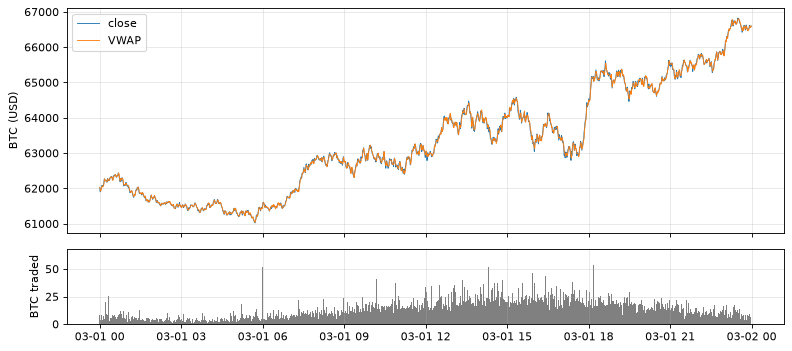

In [6]:
btc = bars.filter(symbol="BTC")
fig, (a, b) = plt.subplots(2, 1, sharex=True, figsize=(10, 4.5), height_ratios=[3, 1])
a.plot(btc["minute"], btc["close"], lw=0.8, label="close")
a.plot(btc["minute"], btc["vwap"], lw=0.8, label="VWAP")
a.legend(); a.set_ylabel("BTC (USD)")
b.bar(btc["minute"], btc["volume"], width=1 / 1440, color="gray"); b.set_ylabel("BTC traded")
fig.tight_layout()

## 2. The quoted spread

The spread between the best bid and ask, in basis points of the mid, averaged per coin and hour:

72 rows in 0.25 s


symbol,spread_bps
str,f64
"""BTC""",0.522778
"""ETH""",1.04652
"""SOL""",3.143878


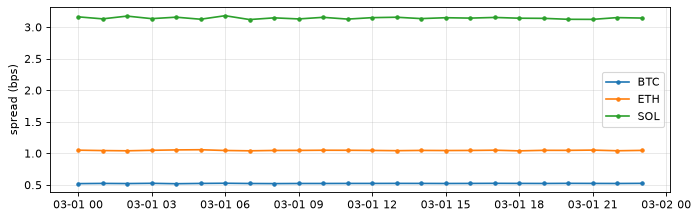

In [7]:
spread = q("""
SELECT date_trunc('hour', ts) AS hour, symbol,
       avg((ask - bid) / ((ask + bid) / 2)) * 1e4 AS spread_bps
FROM quotes
GROUP BY hour, symbol
ORDER BY hour, symbol
""")
fig, a = plt.subplots()
for coin in ["BTC", "ETH", "SOL"]:
    s = spread.filter(symbol=coin)
    a.plot(s["hour"], s["spread_bps"], marker=".", label=coin)
a.set_ylabel("spread (bps)"); a.legend()
spread.group_by("symbol").agg(pl.col("spread_bps").mean()).sort("symbol")

BTC's quotes are about half a basis point wide, ETH's one and SOL's three. The spread is only part of what a trade pays: where its price lands against the mid is the rest.

## 3. What each trade paid

An `ASOF JOIN` pairs every trade with the last quote of its coin at or before it. A buy above the mid, or a sell below it, paid; the cost in basis points of the mid, by coin and by the trade's size in dollars:

In [8]:
cost = q("""
SELECT t.symbol,
       CASE WHEN t.price * t.size < 1000 THEN '1: < $1k' WHEN t.price * t.size < 10000 THEN '2: $1k - 10k'
            WHEN t.price * t.size < 100000 THEN '3: $10k - 100k' ELSE '4: $100k+' END AS size_usd,
       count(*) AS trades,
       avg(CASE WHEN t.side = 'buy' THEN 1 ELSE -1 END * (t.price - (q.bid + q.ask) / 2)
           / ((q.bid + q.ask) / 2)) * 1e4 AS cost_bps
FROM trades t ASOF JOIN quotes q ON t.symbol = q.symbol AND t.ts >= q.ts
GROUP BY t.symbol, size_usd
ORDER BY t.symbol, size_usd
""")
cost.pivot(on="symbol", index="size_usd", values="cost_bps").sort("size_usd")

12 rows in 0.09 s


size_usd,BTC,ETH,SOL
str,f64,f64,f64
"""1: < $1k""",0.346574,0.607436,1.566669
"""2: $1k - 10k""",0.497641,0.759273,1.576139
"""3: $10k - 100k""",0.885755,1.143953,2.366721
"""4: $100k+""",1.993725,2.294969,3.357233


The smallest trades pay about half the spread (0.35 bps on BTC, 1.6 on SOL). The bigger the trade, the more it pays: trades over $100k pay 2 to 3.4 bps, because they walk the book.

## 4. Markouts

Where did the mid go after each trade? The same as-of join at a time offset: the quote in force 1, 10 and 60 seconds later, measured from the trade's price. Positive: the trade was on the right side of the move (the cookbook's [markouts](https://aperiodic-io.github.io/monotile/docs/cookbook.html#markouts) recipe).

3 rows in 0.69 s


symbol,trades,after_1s,after_10s,after_60s
str,u64,f64,f64,f64
"""BTC""",120000,0.314512,0.974514,1.010617
"""ETH""",80000,-0.09048,0.707649,0.770378
"""SOL""",50000,-1.166387,-0.303272,0.024908


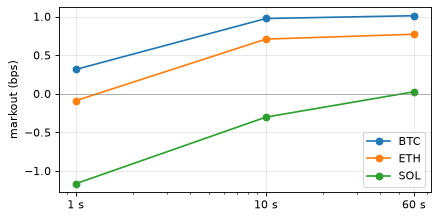

In [9]:
markouts = q("""
SELECT t.symbol, count(*) AS trades,
       avg(CASE WHEN t.side = 'buy' THEN 1 ELSE -1 END * ((q1.bid + q1.ask) / 2 - t.price) / t.price) * 1e4 AS after_1s,
       avg(CASE WHEN t.side = 'buy' THEN 1 ELSE -1 END * ((q10.bid + q10.ask) / 2 - t.price) / t.price) * 1e4 AS after_10s,
       avg(CASE WHEN t.side = 'buy' THEN 1 ELSE -1 END * ((q60.bid + q60.ask) / 2 - t.price) / t.price) * 1e4 AS after_60s
FROM trades t
ASOF JOIN quotes q1 ON t.symbol = q1.symbol AND t.ts + INTERVAL '1 second' >= q1.ts
ASOF JOIN quotes q10 ON t.symbol = q10.symbol AND t.ts + INTERVAL '10 seconds' >= q10.ts
ASOF JOIN quotes q60 ON t.symbol = q60.symbol AND t.ts + INTERVAL '60 seconds' >= q60.ts
GROUP BY t.symbol
ORDER BY t.symbol
""")
fig, a = plt.subplots(figsize=(6, 3))
for row in markouts.iter_rows(named=True):
    a.plot([1, 10, 60], [row["after_1s"], row["after_10s"], row["after_60s"]], marker="o", label=row["symbol"])
a.set_xscale("log"); a.set_xticks([1, 10, 60], ["1 s", "10 s", "60 s"]); a.set_ylabel("markout (bps)"); a.axhline(0, color="gray", lw=0.5); a.legend()
markouts

A second after a BTC trade, the mid is 0.3 bps its way, and a minute after, 1 bp: the trades of the same run that come after it keep pushing the price. SOL's trades pay a wider spread, so they start behind (−1.2 bps after a second) and only break even after a minute.

## 5. Realised volatility

Log returns of the one-minute closes (`lag` over each coin's bars, in a subquery), and their standard deviation by the hour, annualised:

72 rows in 0.03 s


symbol,quietest,busiest
str,f64,f64
"""BTC""",42.843229,138.687279
"""ETH""",39.303433,106.982957
"""SOL""",40.310088,99.315307


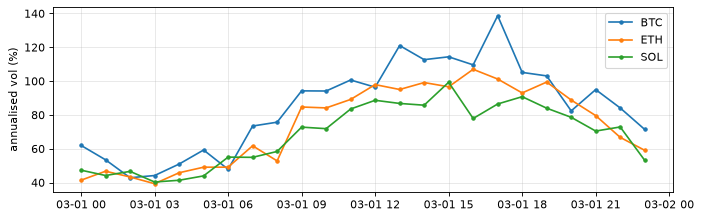

In [10]:
vol = q("""
WITH bars AS (SELECT time_bucket('1m', ts) AS minute, symbol, last(price, ts) AS close FROM trades GROUP BY minute, symbol),
     returns AS (SELECT date_trunc('hour', minute) AS hour, symbol,
                        ln(close / lag(close) OVER (PARTITION BY symbol ORDER BY minute)) AS r FROM bars)
SELECT hour, symbol, stddev(r) * sqrt(525600) * 100 AS vol_pct, count(r) AS minutes
FROM returns
GROUP BY hour, symbol
ORDER BY hour, symbol
""")
fig, a = plt.subplots()
for coin in ["BTC", "ETH", "SOL"]:
    v = vol.filter(symbol=coin)
    a.plot(v["hour"], v["vol_pct"], marker=".", label=coin)
a.set_ylabel("annualised vol (%)"); a.legend()
vol.group_by("symbol").agg(quietest=pl.col("vol_pct").min(), busiest=pl.col("vol_pct").max()).sort("symbol")

Volatility follows activity: from about 40% annualised in the quiet hours to 100-140% in the busiest, where more quotes and trades move the price more often.

## Next

- The same SQL runs over your own Parquet, CSV and JSON files, in S3, over DataFrames, and live: [`brrrrr serve`](https://aperiodic-io.github.io/monotile/docs/server.html) keeps a live view's answer up to date as trades arrive, and [`brrrrr run`](https://aperiodic-io.github.io/monotile/docs/streaming.html) writes it to Kafka exactly once.
- More recipes: the [cookbook](https://aperiodic-io.github.io/monotile/docs/cookbook.html).